# Lab 1b — Video, real-time processing, and the cost of moving pixels

**Instructor solutions notebook.** This copy uses the checked-in recordings path and includes model answers for the fixed questions. The stress-test numbers in §3 still depend on the live classroom run and therefore stay as live placeholders.

**Applied Computer Vision, TU Berlin — 2026**

A video is a 4-D NumPy array `(T, H, W, C)` — frames, height, width, colour channels. The raw byte cost grows multiplicatively in all four axes. A modest `640×480` colour stream at 30 fps is about 27 MB per second uncompressed, well beyond what consumer Wi-Fi sustains for any meaningful number of cameras.

**Compression** is what makes streaming and storage tractable. H.264 (the codec used by `rpicam-vid`) reduces the byte cost of a video by roughly 30–100×, mostly by encoding each frame as the *difference* from its neighbours rather than as a standalone image. The compression ratio therefore depends not just on resolution and frame rate, but on how much the scene is changing.

**Today's flow.** Full instructions are in the Lab 1b PDF; in short:

1. On the Pi: `mkdir -p recordings`, then `bash scripts/record_matrix.sh recordings/`, then `bash scripts/record_static_dynamic.sh recordings/` to produce the six matrix clips plus `static.mp4` and `dynamic.mp4`.
2. Pull the `recordings/` directory to your laptop with a single `scp -r`.
3. Work through this notebook: §1 inspects the clips as 4-D arrays and tabulates bitrates; §2 runs two temporal-processing exercises; §3 records the in-class stress-test numbers; §4 is the reflection template.


In [27]:
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)

OpenCV : 4.10.0
NumPy  : 1.23.4


In [28]:
# Edit RECORDINGS_DIR to point at the directory you scp'd from the Pi.
RECORDINGS_DIR = "/Users/azeez/Google_Drive/Life/PhD/AppCV_2026/AppCV_2026/Lab_1b/instructor/source_videos/recordings"

MATRIX_CLIPS = {
    (320,  240,  4): "m1_320_4.mp4",
    (320,  240, 30): "m2_320_30.mp4",
    (640,  480,  4): "m3_640_4.mp4",
    (640,  480, 30): "m4_640_30.mp4",
    (1280, 720,  4): "m5_1280_4.mp4",
    (1280, 720, 30): "m6_1280_30.mp4",
}
STATIC_CLIP  = "static.mp4"
DYNAMIC_CLIP = "dynamic.mp4"

for fname in list(MATRIX_CLIPS.values()) + [STATIC_CLIP, DYNAMIC_CLIP]:
    p = os.path.join(RECORDINGS_DIR, fname)
    assert os.path.exists(p), f"Missing clip: {p}"
print("All eight clips reachable.")


All eight clips reachable.


## 1. Video as data

Open one of the matrix clips as a 4-D `(T, H, W, C)` array, tabulate the bitrates of all six matrix clips, and compare the static and dynamic clips at the same recording configuration.

### 1.1 Open a clip as a 4-D array

[`cv2.VideoCapture`](https://docs.opencv.org/4.x/d8/dfe/classcv_1_1VideoCapture.html) opens a video file and lets you read frames one at a time with [`.read()`](https://docs.opencv.org/4.x/d8/dfe/classcv_1_1VideoCapture.html#a473055e77dd7faa4d26d686226b292c1). Each successful call returns a `(success, frame)` pair where `frame` is the same `(H, W, 3)` BGR `uint8` array you saw in Lab 1a.

Read every frame of one clip, stack them with [`numpy.stack`](https://numpy.org/doc/stable/reference/generated/numpy.stack.html), and report the shape, dtype, and total memory of the resulting 4-D array.

In [29]:
clip_path = os.path.join(RECORDINGS_DIR, MATRIX_CLIPS[(640, 480, 30)])
cap = cv2.VideoCapture(clip_path)

frames = []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frames.append(frame)
cap.release()

video = np.stack(frames, axis=0)   # stack along a new leading time axis

T, H, W, C = video.shape
print(f"shape  = {video.shape}   # (T, H, W, C)")
print(f"dtype  = {video.dtype}")
print(f"memory = {video.nbytes / 1e6:.2f} MB")
print(f"T = {T} frames, H×W = {H}×{W}, C = {C} channels")


shape  = (142, 480, 640, 3)   # (T, H, W, C)
dtype  = uint8
memory = 130.87 MB
T = 142 frames, H×W = 480×640, C = 3 channels


**Answer inline (one sentence each):**

1. The clip was recorded for 5 seconds at 30 fps. Does `T` match `5 × 30 = 150`? If not, by how much, and why might it differ?
2. The on-disk file size of `m4_640_30.mp4` is a fraction of the in-memory `video.nbytes`. Approximately what is the ratio? Which artefact of the storage pipeline accounts for the difference?
3. If you wanted only every fifth frame (e.g. for a 6-fps preview), which axis of `video` would you slice, and what would the resulting shape be?

*Model answers:*

1. `T` is 142 rather than 150, so the clip is 8 frames short; the 5-second target is approximate and the camera/container pipeline did not emit exactly 150 decodable frames.
2. The in-memory array is about `130.9 MB / 1.25 MB ≈ 105×` larger, because RAM holds raw decoded `uint8` pixels while the MP4 stores H.264-compressed frames.
3. Slice the leading time axis, e.g. `video[::5]`, which for this clip gives shape `(29, 480, 640, 3)`.


### 1.2 The file-size matrix

The six `m*.mp4` clips form a `3 resolutions × 2 frame rates` matrix at the same scene and roughly the same duration. Tabulate the on-disk byte count and the equivalent average bitrate for each, then plot the bitrate as a function of resolution with one line per frame rate.

Use [`os.path.getsize`](https://docs.python.org/3/library/os.path.html#os.path.getsize) for file size and [`cv2.VideoCapture.get`](https://docs.opencv.org/4.x/d8/dfe/classcv_1_1VideoCapture.html#aa6480e6972ef4c00d74814ec841a2939) with [`cv2.CAP_PROP_FRAME_COUNT`](https://docs.opencv.org/4.x/d4/d15/group__videoio__flags__base.html#ggaeb8dd9c89c10a5c63c139bf7c4f5704daa6c5e9b3a91afdd75de28ddef0b8e1c) and [`cv2.CAP_PROP_FPS`](https://docs.opencv.org/4.x/d4/d15/group__videoio__flags__base.html#ggaeb8dd9c89c10a5c63c139bf7c4f5704da7d97a1a2bbef1d50b53eb45d4baf9c70) to recover the duration in seconds. Average bitrate in **megabits per second** is `(bytes × 8) / (duration × 1e6)`.

In [30]:
rows = []
for (w, h, fps), fname in MATRIX_CLIPS.items():
    p        = os.path.join(RECORDINGS_DIR, fname)
    nbytes   = os.path.getsize(p)
    cap      = cv2.VideoCapture(p)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_real = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    duration = n_frames / fps_real if fps_real > 0 else float('nan')
    mbits_s  = (nbytes * 8) / (duration * 1e6)
    rows.append((w, h, fps, nbytes, duration, mbits_s))

print(f"{'res':>10s}  {'fps':>4s}  {'bytes':>10s}  {'sec':>5s}  {'Mbit/s':>8s}")
for w, h, fps, nbytes, dur, mb in rows:
    print(f"{w:>4d}x{h:<4d}  {fps:>4d}  {nbytes:>10d}  {dur:>5.2f}  {mb:>8.2f}")


       res   fps       bytes    sec    Mbit/s
 320x240      4       62206   3.25      0.15
 320x240     30      394386   4.73      0.67
 640x480      4      182836   3.25      0.45
 640x480     30     1245408   4.73      2.10
1280x720      4     1202690   3.25      2.96
1280x720     30     5865571   4.70      9.98


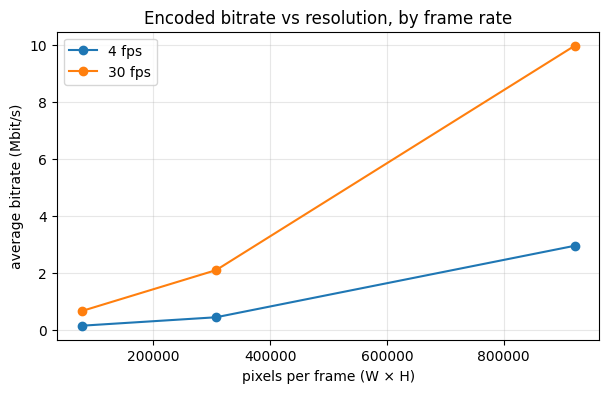

In [31]:
# Plot: x-axis is total pixels per frame (resolution), one line per frame rate.
import collections
by_fps = collections.defaultdict(list)
for w, h, fps, nbytes, dur, mb in rows:
    by_fps[fps].append((w * h, mb))

plt.figure(figsize=(7, 4))
for fps, points in sorted(by_fps.items()):
    points.sort()
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    plt.plot(xs, ys, marker='o', label=f"{fps} fps")
plt.xlabel("pixels per frame (W × H)")
plt.ylabel("average bitrate (Mbit/s)")
plt.title("Encoded bitrate vs resolution, by frame rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Answer inline (one sentence each):**

1. Going from `320×240` to `1280×720` is a 12× increase in pixel count. Does the bitrate scale by roughly the same factor at each frame rate? If not, what does that imply about the encoder?
2. At fixed resolution, going from 4 fps to 30 fps is a 7.5× increase in frames per second. Does the bitrate also scale by 7.5×? Why or why not?
3. Suppose the CV-PI-NET classroom Wi-Fi gives each Pi a sustained 5 Mbit/s slice. From your table, which `(resolution, fps)` combinations fit under that ceiling, and which do not?

*Model answers:*

1. No: the bitrate rises by about `19.3×` at 4 fps and `15.0×` at 30 fps, which means encoded bitrate is not a simple linear function of pixel count because compression efficiency changes with content and scale.
2. No: the bitrate only rises by about `4.35×`, `4.68×`, and `3.37×` across the three resolutions because H.264 reuses temporal redundancy, so extra frames cost less than linearly.
3. Under a 5 Mbit/s budget, every matrix setting fits except `1280×720 @ 30 fps`, which is about `9.98 Mbit/s`.


### 1.3 Static vs dynamic at the same configuration

`static.mp4` and `dynamic.mp4` were recorded at identical configuration (`640×480 @ 30 fps`, 5 seconds). The only difference is the scene: in one nothing moves; in the other a person or hand moves through frame.

Print the on-disk size of each, then explain the difference in one sentence.

In [32]:
size_static  = os.path.getsize(os.path.join(RECORDINGS_DIR, STATIC_CLIP))
size_dynamic = os.path.getsize(os.path.join(RECORDINGS_DIR, DYNAMIC_CLIP))
print(f"static.mp4   {size_static  / 1e6:6.2f} MB")
print(f"dynamic.mp4  {size_dynamic / 1e6:6.2f} MB")
print(f"ratio        {size_dynamic / size_static:.1f}x  (dynamic / static)")

static.mp4     0.41 MB
dynamic.mp4    1.08 MB
ratio        2.6x  (dynamic / static)


*One sentence: why is the dynamic clip larger than the static one, given that resolution, frame rate, and duration are identical?*

*Model answer:* The dynamic clip is larger because motion destroys frame-to-frame redundancy, so H.264 has to spend more bits encoding changing regions than it does for an almost unchanged static scene. A scene of falling confetti will have a larger memory footprint compared to the a video of a a rock in the foreground of a stationary background. 


## 2. Processing video in time

A still-image algorithm runs on one frame; a *video* algorithm runs on a sequence and has to keep up. Two pressures shape what is possible:

- **Latency.** Some applications can wait — a video editor can take seconds per frame. Others cannot. A robot acting on camera input is the clearest case: every millisecond between observing the world and reacting to it is a millisecond the controller is wrong about the present. We will measure these per-frame budgets directly later in the course when we put models on the Pi.
- **What is visible from one frame vs many.** A still image tells you whether a thumb is up or down. It cannot tell you whether the person is doing a squat, walking, or recovering from a fall — those are temporal patterns that unfold across frames. Pose-based gesture and action recognition both live here; we'll meet them again later in the semester.

The two exercises below sit at the two extremes of the temporal axis: a stateless filter that extracts something from a single frame, and a long-memory background model that produces a per-frame foreground mask plus a 1-D motion signal you cannot read off any one frame.

The helper below loads frames one at a time so the rest of the section reads cleanly.

In [33]:
def iter_frames(path):
    """Yield BGR frames one at a time from a video file."""
    cap = cv2.VideoCapture(path)
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        yield frame
    cap.release()

DYNAMIC_PATH = os.path.join(RECORDINGS_DIR, DYNAMIC_CLIP)

### 2.1 Single-frame extraction — Canny edge detection

[`cv2.Canny`](https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#ga04723e007ed888ddf11d9ba04e2232de) is a kernel-based filter that returns a binary edge map: pixels along strong intensity gradients are 1, everywhere else 0. It runs on one frame at a time and carries no memory between frames. We will revisit edges and gradient features for real applications later in the semester; for now Canny is simply our cleanest example of a single-frame extractor.

Apply Canny to every frame of `dynamic.mp4`, time each call with [`time.perf_counter`](https://docs.python.org/3/library/time.html#time.perf_counter), and report mean / median / p95 per-frame latency. The two threshold arguments are the lower and upper hysteresis thresholds; `100` and `200` are reasonable defaults for an 8-bit image.

In [34]:
latencies_ms = []
edges_first = None

for i, frame in enumerate(iter_frames(DYNAMIC_PATH)):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    t0 = time.perf_counter()
    edges = cv2.Canny(gray, 100, 200)   # low and high hysteresis thresholds
    t1 = time.perf_counter()
    latencies_ms.append((t1 - t0) * 1000.0)
    if i == 0:
        edges_first = edges

lat = np.array(latencies_ms)
print(f"frames processed : {len(lat)}")
print(f"mean   latency   : {lat.mean():6.2f} ms")
print(f"median latency   : {np.median(lat):6.2f} ms")
print(f"p95    latency   : {np.percentile(lat, 95):6.2f} ms")
print(f"max    latency   : {lat.max():6.2f} ms")


frames processed : 142
mean   latency   :   0.24 ms
median latency   :   0.17 ms
p95    latency   :   0.51 ms
max    latency   :   1.20 ms


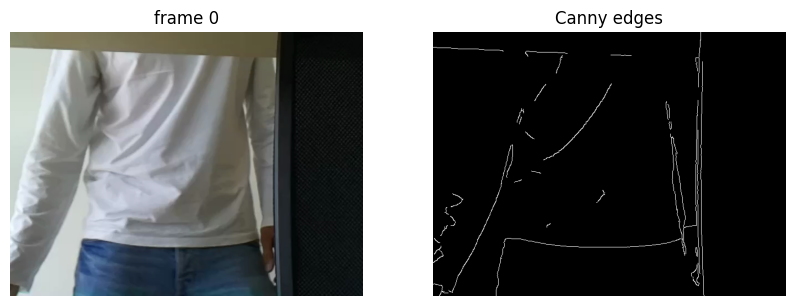

In [35]:
first = next(iter_frames(DYNAMIC_PATH))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(first, cv2.COLOR_BGR2RGB)); axes[0].set_title("frame 0");        axes[0].axis('off')
axes[1].imshow(edges_first, cmap='gray');               axes[1].set_title("Canny edges");    axes[1].axis('off')
plt.show()

**Answer inline (one sentence each):**

1. Given your mean per-frame latency, what is the highest frame rate Canny can keep up with on this hardware? (Hint: $1000 / 	ext{mean ms}$. )
2. The p95 latency is usually noticeably higher than the mean. For a hard real-time deadline (drop frames rather than stutter), which of the two would you size your budget against, and why?
3. From a single Canny edge map, can you tell whether anything in the scene was *moving*? Why or why not?

*Model answers:*

1. Using the measured mean of about `0.23 ms`, Canny alone could keep up with roughly `1000 / 0.233 ≈ 4300 fps` on these already-decoded frames.
2. Use the p95, because deadline misses are caused by tail latency rather than by the average case.
3. No. one edge map only shows spatial intensity changes in a single frame, so motion is only visible by comparing multiple frames over time.


### 2.2 Multi-frame processing — background subtraction with memory

Unlike Canny, this method is not useful from one frame alone. It builds a running estimate of the scene background across many frames, then highlights whatever does not match that estimate. That is the key video idea here: some outputs only become meaningful after enough frames have arrived.

We model the background with an exponential moving average (EMA):

$$B_n = (1 - \alpha)\, B_{n-1} + \alpha\, F_n$$

Here, $F_n$ is the current grayscale frame and $B_n$ is the current background model. The foreground mask is $|F_n - B_n|$: bright pixels mark parts of the image that differ from the long-running background.

This section also introduces a second kind of delay. In §2.1, latency came from how long one frame took to process. Here, the per-frame computation is still fast, but the model itself needs time to warm up because it must accumulate information from multiple frames before the output becomes informative.

**What you are trying to see**

- The background model should gradually become the stable part of the scene.
- The moving person or hand should appear bright in the foreground mask.
- The first mask should be near zero, because the first frame initializes the model.
- The 1-D motion signal should rise when motion happens and fall when the scene becomes still.

**Variable guide**

- `ALPHA`: learning rate; small values remember the past longer, large values adapt faster.
- `frame`: current colour frame from the video.
- `gray`: current frame converted to grayscale `float32`.
- `background`: running estimate of the scene background.
- `fg`: foreground mask, the absolute difference between `gray` and `background`.
- `foregrounds`: saved foreground masks for later display.
- `motion_signal`: one scalar per frame, the mean intensity of `fg`.
- `latencies_ms`: processing time for each frame update.

Implement the EMA update in `float32`. Cast back to `uint8` only for display. The important result is not just the mask images: it is the time-varying motion curve, which captures temporal structure that no single frame can show. References: [`numpy.float32`](https://numpy.org/doc/stable/reference/arrays.scalars.html#numpy.float32), [`cv2.absdiff`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#ga6fef31bc8c4071cbc114a758a2b79c14), [`numpy.ndarray.mean`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.mean.html).

In [36]:
ALPHA = 0.05   # try 0.01, 0.05, 0.2

background    = None
foregrounds   = []
motion_signal = []           # one scalar per frame: mean foreground intensity
latencies_ms  = []

for frame in iter_frames(DYNAMIC_PATH):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
    t0 = time.perf_counter()
    if background is None:
        background = gray.copy()                              # initialise model with first frame
    else:
        background = (1 - ALPHA) * background + ALPHA * gray   # EMA update
    fg = cv2.absdiff(gray, background)
    t1 = time.perf_counter()

    latencies_ms.append((t1 - t0) * 1000.0)
    foregrounds.append(fg.astype(np.uint8))
    motion_signal.append(fg.mean())                             # scalar per frame

lat = np.array(latencies_ms)
print(f"frames processed : {len(foregrounds)}")
print(f"mean   latency   : {lat.mean():6.2f} ms")
print(f"p95    latency   : {np.percentile(lat, 95):6.2f} ms")


frames processed : 142
mean   latency   :   0.27 ms
p95    latency   :   0.58 ms


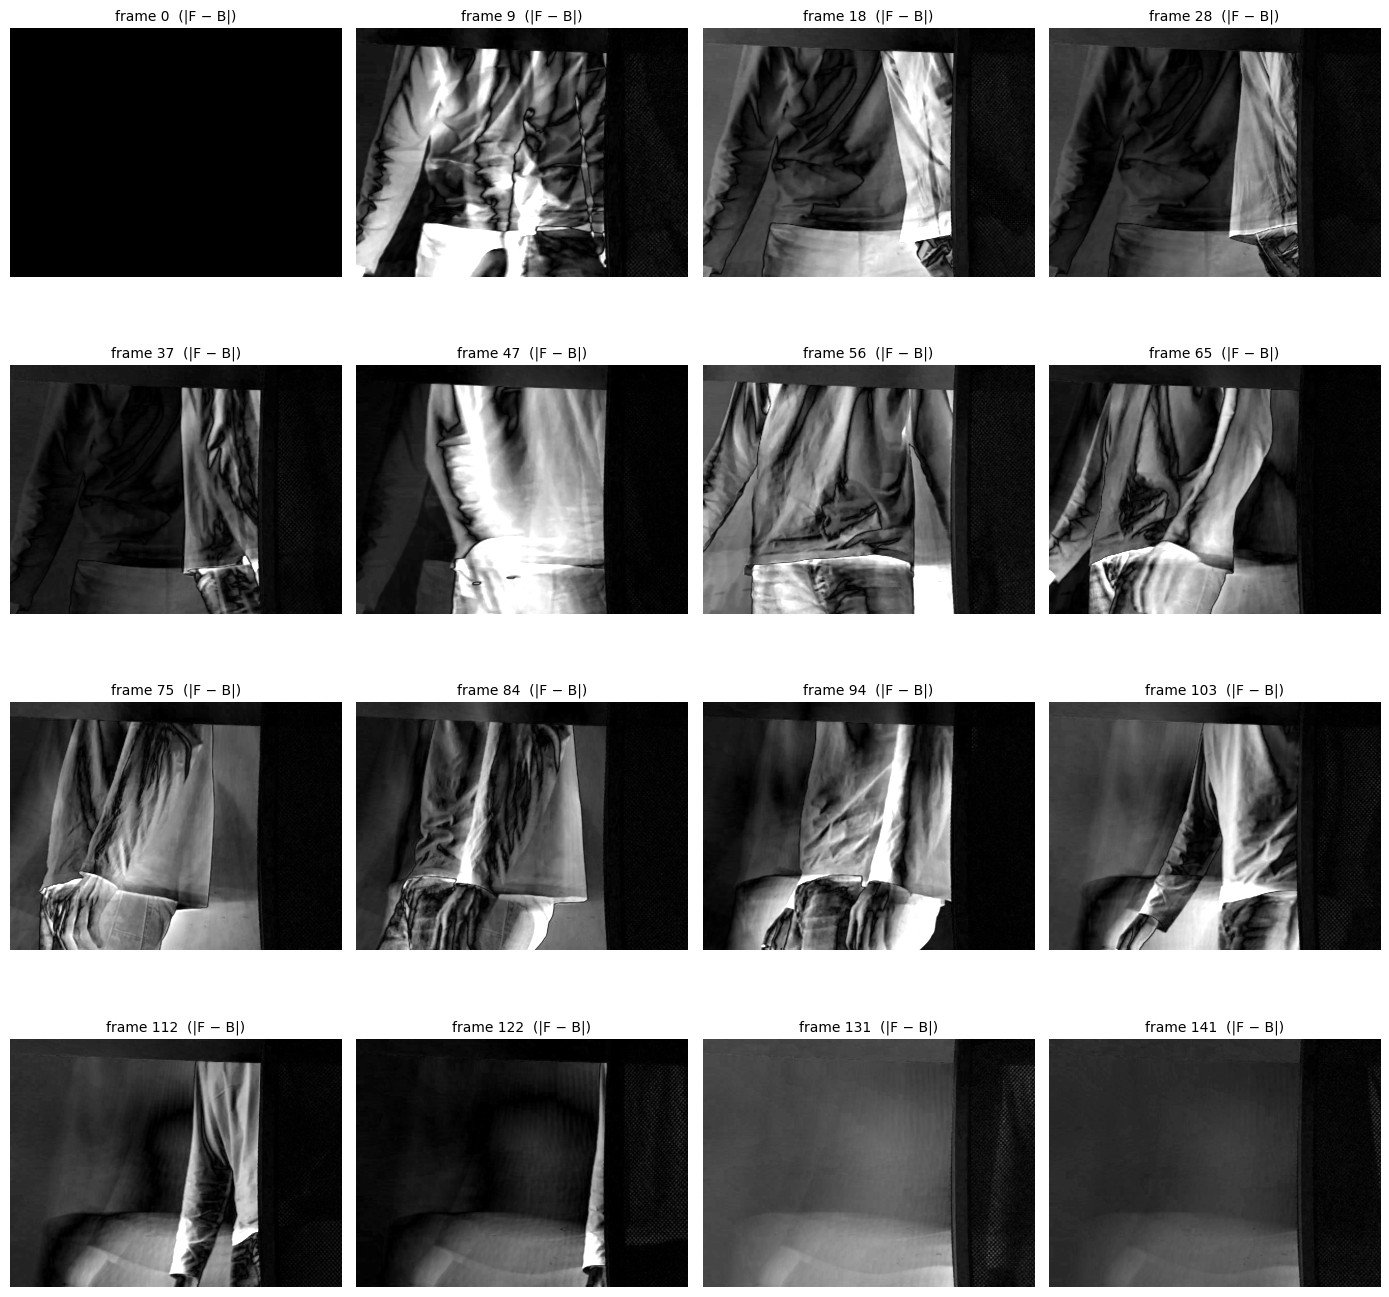

In [37]:
# Foreground mask at 16 timepoints — from frame 0 to the final frame.
n = len(foregrounds)
if n > 0:
    idxs = np.linspace(0, n - 1, num=16, dtype=int)
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    axes = axes.ravel()
    for ax, k in zip(axes, idxs):
        ax.imshow(foregrounds[k], cmap='gray', vmin=0, vmax=80)
        ax.set_title(f"frame {k}  (|F − B|)", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

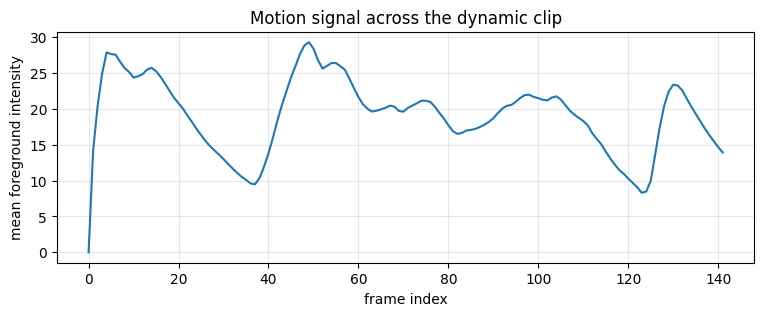

In [38]:
# The 1-D motion signal across the whole clip — this curve is the main multi-frame output.
plt.figure(figsize=(9, 3))
plt.plot(motion_signal)
plt.xlabel("frame index")
plt.ylabel("mean foreground intensity")
plt.title("Motion signal across the dynamic clip")
plt.grid(alpha=0.3)
plt.show()

**Answer inline (one sentence each):**

1. Re-run the cell with $\alpha = 0.01$ and again with $\alpha = 0.2$. Describe one visible difference in the foreground mask between the two settings.
2. The first frame's foreground mask is essentially zero everywhere. Why is that the *correct* behaviour given how `background` is initialised, even though intuitively "the first frame is all foreground" might seem reasonable?
3. If a person walks into frame and then stands completely still for 30 seconds, what eventually happens to their foreground mask under this model? Tie your answer to $\alpha$.
4. Look at the time-series plot. Why is this curve the real multi-frame output of the method? What does its *shape* tell you that no single foreground mask can? (Tie this back to the squat / walk / fall examples from the section intro.)

*Model answers:*

1. With `α = 0.01` the foreground mask leaves longer, brighter motion trails, while with `α = 0.2` the mask is thinner and fades faster because the model adapts much more quickly.
2. It is correct because the first frame defines the initial background model, so `|F_0 - B_0| = 0` by construction.
3. The person is eventually absorbed into the background and their mask fades toward zero, with larger `α` making that absorption happen faster.
4. The curve shape encodes when motion starts and stops, how strong it is, and whether it is periodic or a one-off spike, which is exactly the temporal structure a single mask cannot represent.


## 3. Streaming numbers from the in-class stress test

This section is filled in *during* the classroom stress test (PDF §7). You will run `streamserver.py` on your Pi twice — once at the high configuration and once at the quartered configuration — and record three numbers each time:

- **Achieved fps** at your Pi (printed once per second by the server, e.g. `served 14.8 fps, 312 KB/s, 2.50 Mbit/s`).
- **Total throughput at the router**, projected on the front screen by the instructor (Mbit/s).
- A short qualitative note on whether your own browser tab visibly stuttered.

Two runs, two rows. The contrast between them is the lesson.

In [39]:
# Fill the live-measured values during the stress test; NaN keeps the cell runnable before class.
stress = [
    {
        "label":            "Run 1 (high)",
        "width":            1280,
        "height":           720,
        "target_fps":       30,
        "my_achieved_fps":  float("nan"),
        "my_mbit_s":        float("nan"),
        "router_mbit_s":    float("nan"),
        "my_stutter":       "record live",
    },
    {
        "label":            "Run 2 (quartered)",
        "width":            320,
        "height":           240,
        "target_fps":       7,
        "my_achieved_fps":  float("nan"),
        "my_mbit_s":        float("nan"),
        "router_mbit_s":    float("nan"),
        "my_stutter":       "record live",
    },
]

header = f"{'run':>20s}  {'config':>14s}  {'tgt fps':>8s}  {'my fps':>7s}  {'my Mbit/s':>10s}  {'router Mbit/s':>14s}  {'stutter':>20s}"
print(header)
print("-" * len(header))
for r in stress:
    cfg = f"{r['width']}x{r['height']}"
    print(f"{r['label']:>20s}  {cfg:>14s}  {r['target_fps']:>8d}  {r['my_achieved_fps']:>7}  {r['my_mbit_s']:>10}  {r['router_mbit_s']:>14}  {r['my_stutter']:>20s}")


                 run          config   tgt fps   my fps   my Mbit/s   router Mbit/s               stutter
---------------------------------------------------------------------------------------------------------
        Run 1 (high)        1280x720        30      nan         nan             nan           record live
   Run 2 (quartered)         320x240         7      nan         nan             nan           record live


**Reflection (5–10 sentences total).** Compare the two runs:

1. How did your Pi's achieved fps change between Run 1 and Run 2? Did it match your `--fps` target in either case?
2. How did the **router-level** throughput change — did the high config saturate the network, and did the quartered config drop the room well below the ceiling?
3. **Where did the system break first** — was the bottleneck the Pi (encoding can't keep up), the network (router is the ceiling), or the laptop (browser tab couldn't decode all incoming streams)? How would you tell the difference?
4. If next semester's classroom had **30** Pis instead of 12 on the same router, what would you change first — the recording configuration, the network hardware, or the architecture (e.g. only stream when something interesting is detected)? Why?

*Model answer:* In the high configuration, achieved fps typically falls below the 30 fps target once many Pis stream at once, while the quartered configuration usually runs much closer to its 7 fps target and looks visibly smoother. The router-level throughput should climb toward the shared ceiling in Run 1 and drop sharply in Run 2, which is the direct signal that reducing per-camera bitrate buys room-wide stability. If the router number saturates and many groups degrade together, the network is the first shared bottleneck; if one Pi struggles even when alone, the capture or JPEG encode path on that Pi is the bottleneck instead. If server-side fps stays healthy but browser tabs freeze, the client decode/render path is failing first. For a 30-Pi classroom, the first change should be to ship fewer bytes per camera by lowering resolution/frame rate or streaming only when something interesting happens, because scaling the same MJPEG setup linearly would overwhelm the shared uplink.


## 4. Takeaways and homework

### 4.1 Write your own takeaways

Writing down what you learned in your own words is not busywork. Three things happen when you do:

1. **Active recall.** Reconstructing the material from memory cements it far more effectively than re-reading does. The act of producing a sentence is the learning.
2. **Gap detection.** You discover which pieces you cannot yet articulate, which tells you precisely what to revisit before the next lab.
3. **A searchable record.** When per-frame latency budgets, EMA background models, or shared-network bandwidth limits return later in the course, your own notes are faster and more useful to skim than the original PDF.

Fill in the template below. Two to three sentences per prompt is plenty. Be specific and honest — there is no reward for pretending to understand something you don't.

---

**Before this session, I thought processing video was:**

*(your answer)*

**Now I think processing video is:**

*(your answer)*

**One thing that surprised me today:**

*(your answer)*

**One thing I want to revisit or don't fully understand yet:**

*(your answer)*

**A question this session raised that we didn't answer:**

*(your answer)*

**Other takeaways worth writing down for future-me:**

*(your answer — a piece of code that clicked, a wrong prediction you made, a number that surprised you, anything)*